In [1]:
import jax
from jax import numpy as jnp

In [2]:
CounterState = int

class CounterV2:

  def count(self, n: CounterState) -> tuple[int, CounterState]:
    # You could just return n+1, but here we separate its role as 
    # the output and as the counter state for didactic purposes.
    return n+1

  def reset(self) -> CounterState:
    return 0

counter = CounterV2()
state = counter.reset()

for _ in range(3):
  state = counter.count(state)
  print(state)

1
2
3


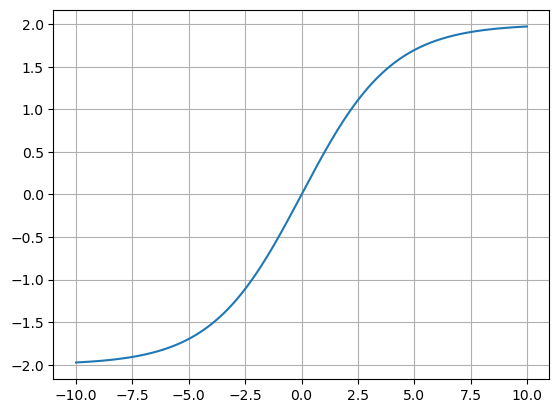

In [10]:
import matplotlib.pyplot as plt
import numpy as np

gamma = 4
g = 0.5
beta = -gamma/2

h = np.arange(-10,10,0.01)

f = gamma / (1+np.exp(-g*h)) + beta

plt.plot(h,f)
plt.grid(True)

In [3]:
state = 0
fast_count = jax.jit(counter.count)

for _ in range(3):
  state = fast_count(state)
  print(state)

1
2
3


In [ ]:
x = jnp.linspace(-10, 10, 100)  # x-coordinates
y = jnp.linspace(-10, 10, 100)  # y-coordinates
x_grid, y_grid = jnp.meshgrid(x, y)  # Create the grid

# Combine x and y into Cartesian coordinates
coords = jnp.stack([x_grid, y_grid], axis=-1)
print(coords.shape)  # Shape will be (100, 100, 2)
print(coords[])


(100, 100, 2)


In [ ]:
import numpy as np
np.mean(2)

NameError: name 'np' is not defined

In [4]:
type(state)

jaxlib.xla_extension.ArrayImpl

In [5]:
from typing import NamedTuple

class Params(NamedTuple):
  weight: jnp.ndarray
  bias: jnp.ndarray


def init(rng) -> Params:
  """Returns the initial model params."""
  weights_key, bias_key = jax.random.split(rng)
  weight = jax.random.normal(weights_key, ())
  bias = jax.random.normal(bias_key, ())
  return Params(weight, bias)


def loss(params: Params, x: jnp.ndarray, y: jnp.ndarray) -> jnp.ndarray:
  """Computes the least squares error of the model's predictions on x against y."""
  pred = params.weight * x + params.bias
  return jnp.mean((pred - y) ** 2)


LEARNING_RATE = 0.005

@jax.jit
def update(params: Params, x: jnp.ndarray, y: jnp.ndarray) -> Params:
  """Performs one SGD update step on params using the given data."""
  grad = jax.grad(loss)(params, x, y)

  # If we were using Adam or another stateful optimizer,
  # we would also do something like
  #
  #   updates, new_optimizer_state = optimizer(grad, optimizer_state)
  # 
  # and then use `updates` instead of `grad` to actually update the params.
  # (And we'd include `new_optimizer_state` in the output, naturally.)

  new_params = jax.tree.map(
      lambda param, g: param - g * LEARNING_RATE, params, grad)

  return new_params

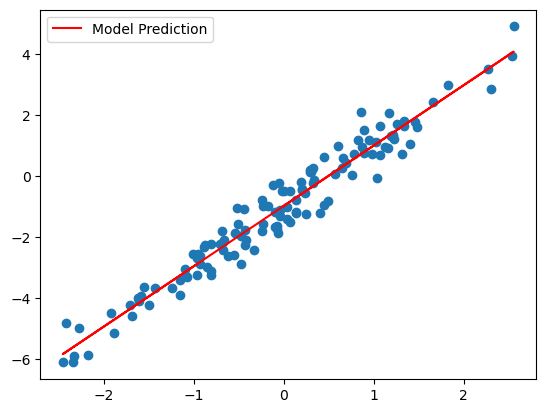

In [10]:
import matplotlib.pyplot as plt

rng = jax.random.key(42)

# Generate true data from y = w*x + b + noise
true_w, true_b = 2, -1
x_rng, noise_rng = jax.random.split(rng)
xs = jax.random.normal(x_rng, (128, 1))
noise = jax.random.normal(noise_rng, (128, 1)) * 0.5
ys = xs * true_w + true_b + noise

# Fit regression
params = init(rng)
for _ in range(1000):
  params = update(params, xs, ys)

plt.scatter(xs, ys)
plt.plot(xs, params.weight * xs + params.bias, c='red', label='Model Prediction')
plt.legend()

In [32]:
@jax.jit
def g(x):
  y = 0.
  for i in range(100):
    y = y + x[i]
  x += 1
  return y

print(g(jnp.array([1., 2., 3.])))

297.0


In [36]:
print(g(jnp.array([1., 2., 5.])))

493.0
